### ZNS-2858 아마존 Top 4 경쟁사 ASP + Traffic

Y축 범위 (전 브랜드 공통):
  revM        :     0.00 ~    31.56
  trafM       :     0.00 ~     3.02
  adK         :     0.00 ~   708.68
  asp         :    70.00 ~   300.00
  cvr_pct     :     1.79 ~    18.12
  tacos_pct   :    -0.70 ~    16.05
saved: ./funnel_ZINUS.png


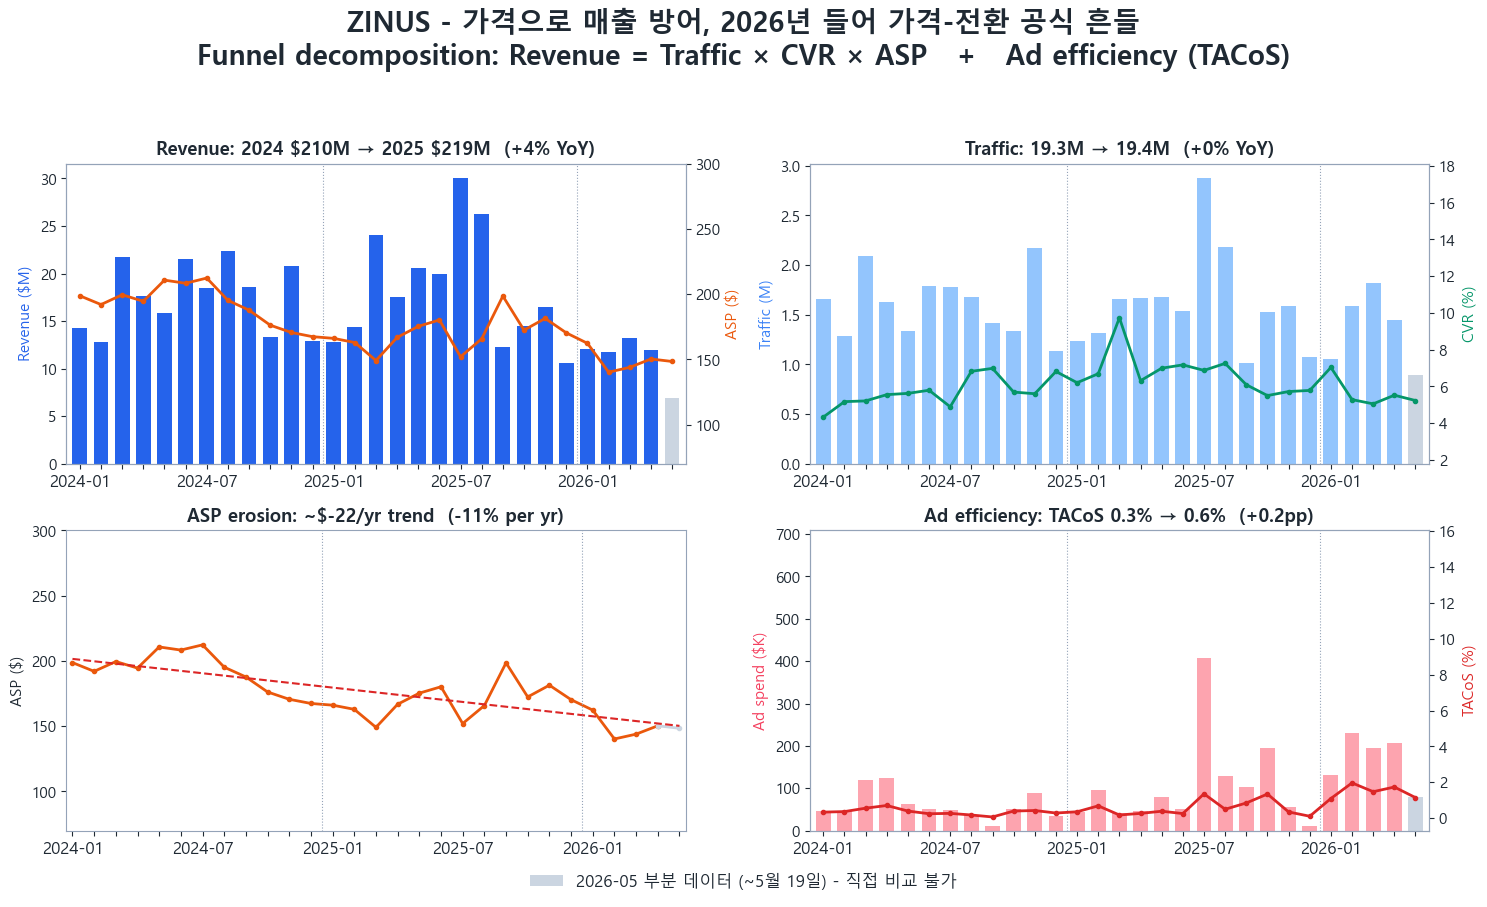

saved: ./funnel_FDW.png


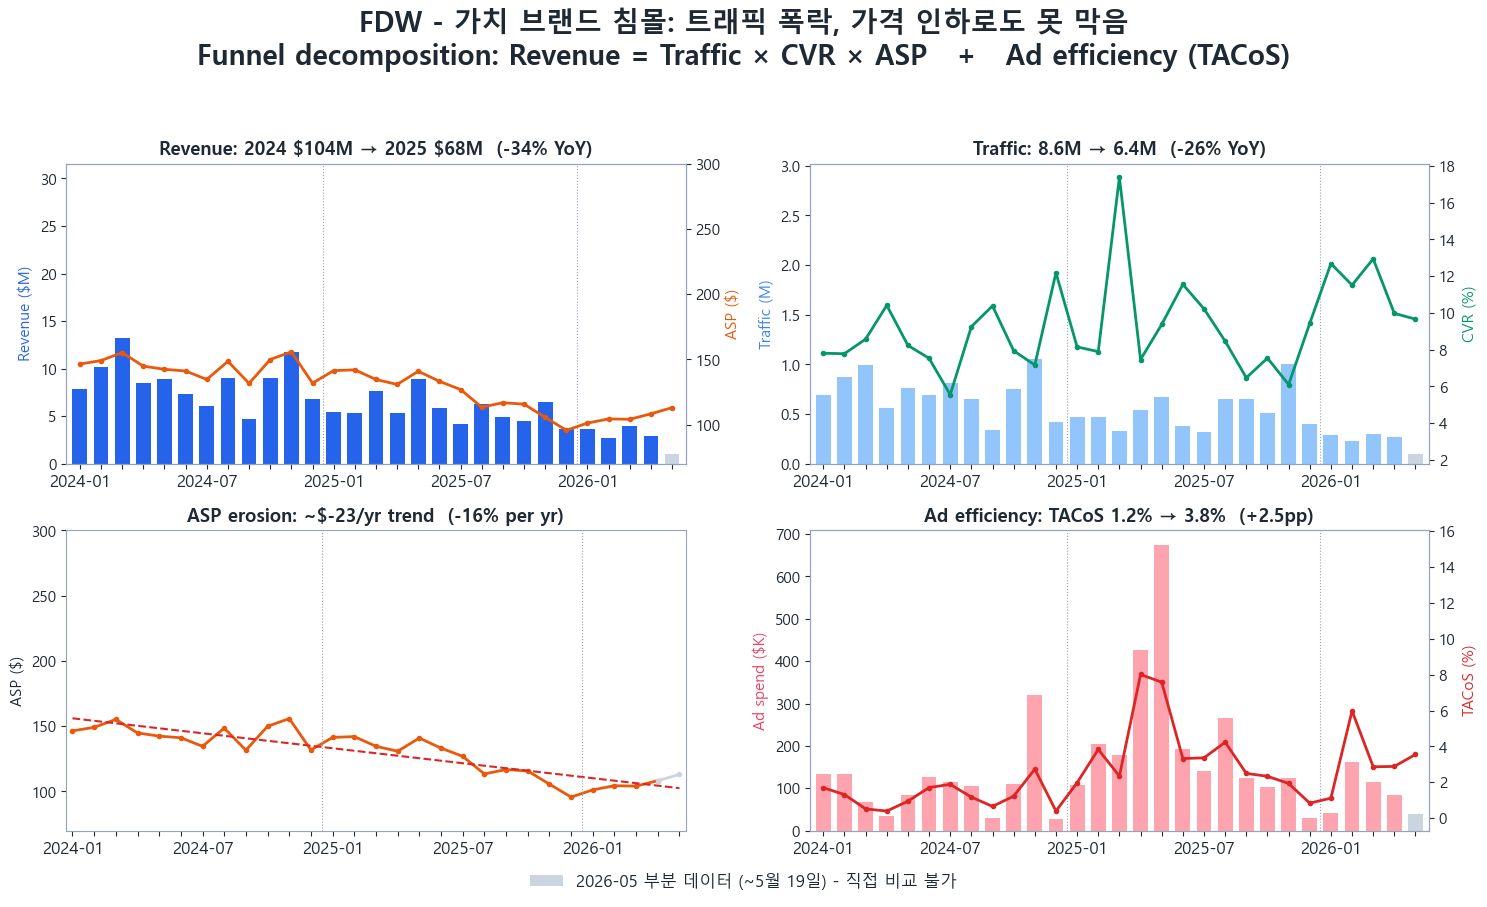

saved: ./funnel_NOVILLA.png


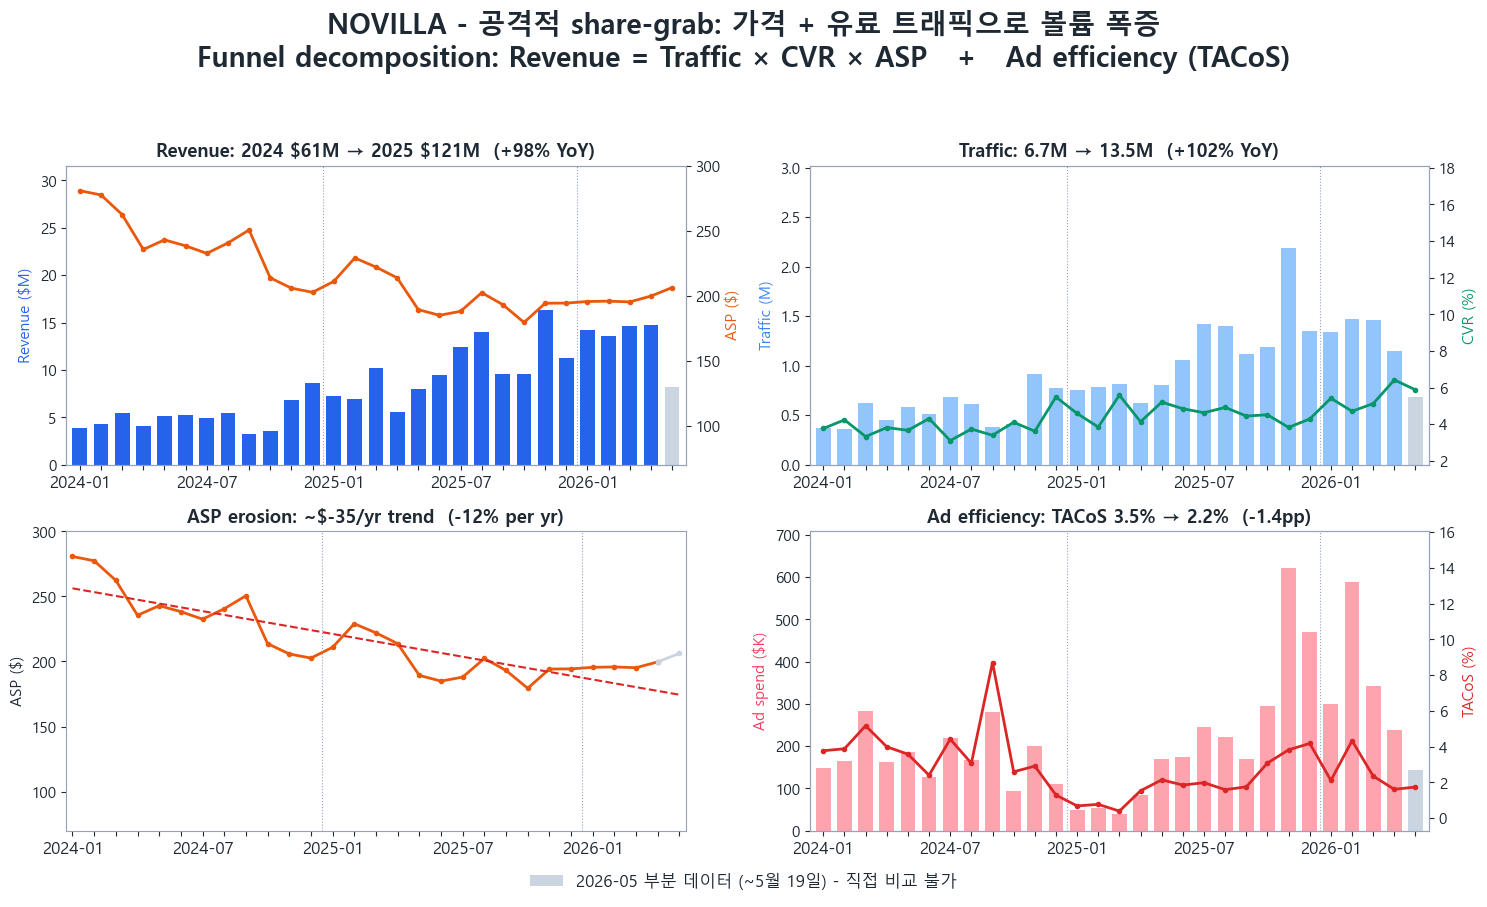

saved: ./funnel_MLILY.png


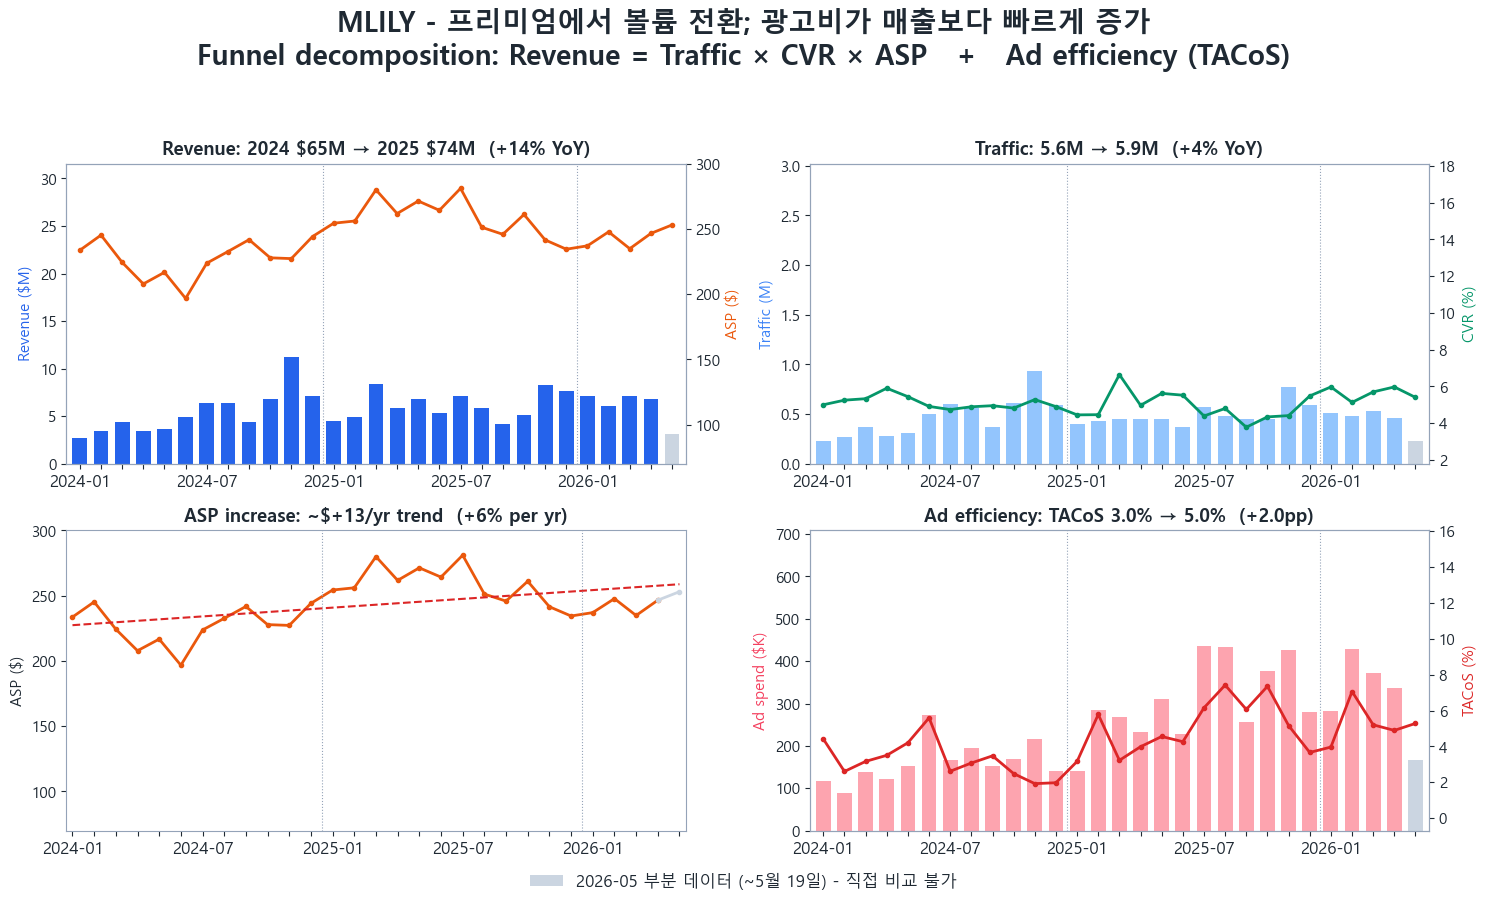

saved: ./funnel_EGOHOME.png


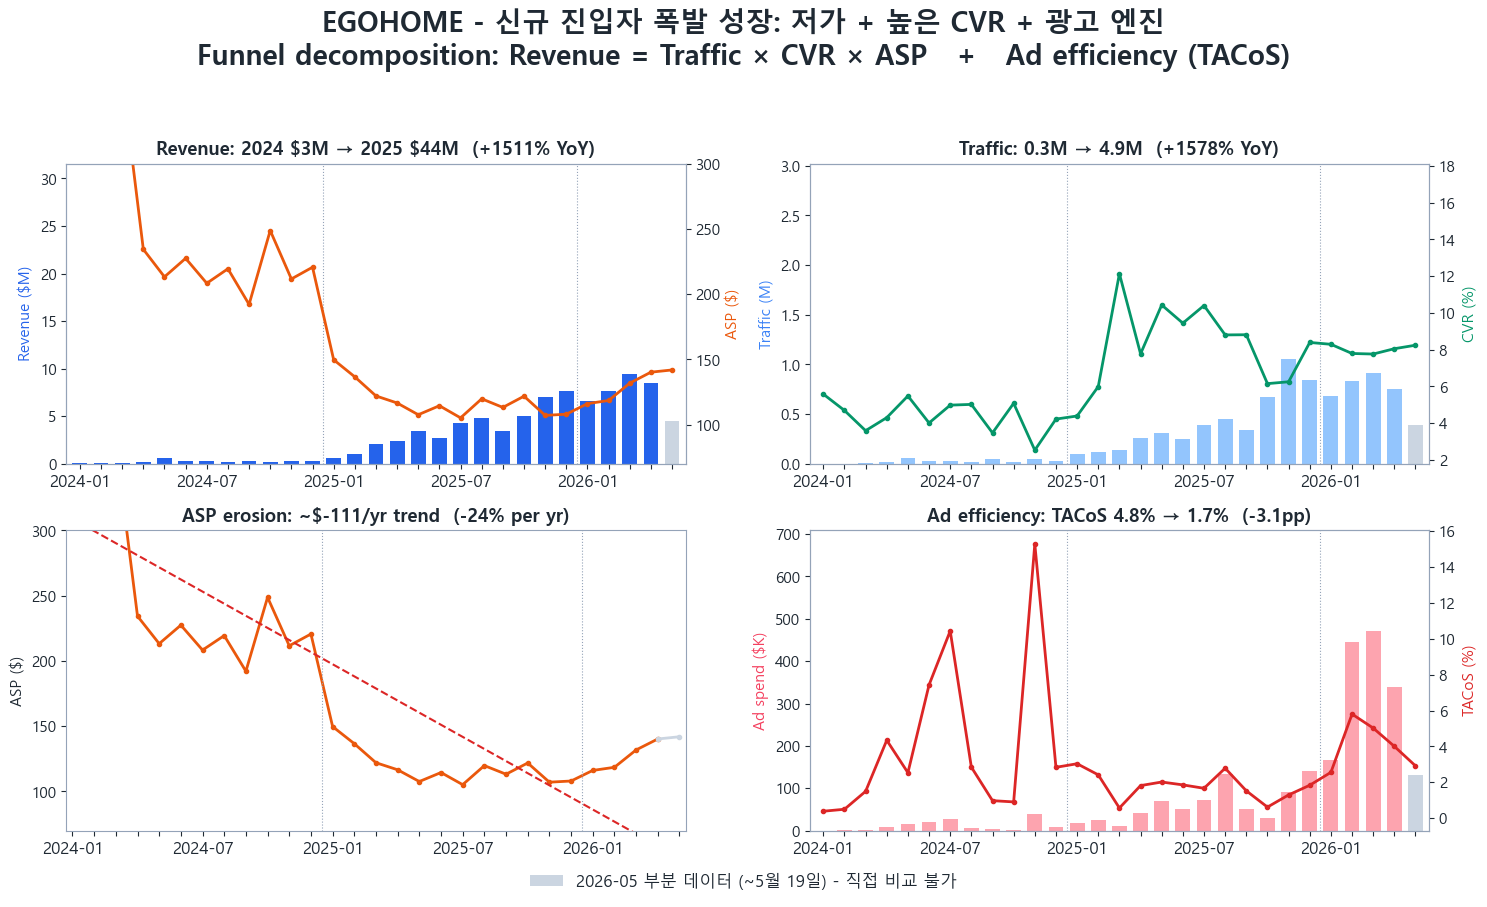

In [19]:
"""
브랜드별 Funnel 분석 4-panel 차트 - Y축 통일 버전
- 5개 브랜드 비교를 위해 각 지표의 y축 범위를 전 데이터셋 기준으로 고정
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# ============================================================
# 설정
# ============================================================
CSV_PATH    = 'data_202605201336.csv'
PARTIAL_MO  = '2026-05'
SAVE_FILES  = True
OUT_DIR     = '.'
BRANDS      = ['ZINUS', 'FDW', 'NOVILLA', 'MLILY', 'EGOHOME']

# 한글 폰트 + $ 처리
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.parse_math'] = False

# 색상 팔레트
INK        = '#1f2933'
BLUE       = '#2563eb'
LIGHT_BLUE = '#93c5fd'
ORANGE     = '#ea580c'
GREEN      = '#059669'
RED        = '#dc2626'
PINK       = '#fda4af'
GREY       = '#cbd5e1'

plt.rcParams.update({
    'font.size': 11, 'axes.edgecolor': '#94a3b8', 'axes.labelcolor': INK,
    'text.color': INK, 'xtick.color': INK, 'ytick.color': INK,
})

STORIES = {
    'ZINUS':   'ZINUS - 가격으로 매출 방어, 2026년 들어 가격-전환 공식 흔들',
    'FDW':     'FDW - 가치 브랜드 침몰: 트래픽 폭락, 가격 인하로도 못 막음',
    'NOVILLA': 'NOVILLA - 공격적 share-grab: 가격 + 유료 트래픽으로 볼륨 폭증',
    'MLILY':   'MLILY - 프리미엄에서 볼륨 전환; 광고비가 매출보다 빠르게 증가',
    'EGOHOME': 'EGOHOME - 신규 진입자 폭발 성장: 저가 + 높은 CVR + 광고 엔진',
}

# ============================================================
# 데이터 로드
# ============================================================
df = pd.read_csv(CSV_PATH).sort_values(['brand', 'yr_month']).reset_index(drop=True)

# ============================================================
# 전역 Y축 범위 계산 (★ 핵심 추가 부분 ★)
# ------------------------------------------------------------
# 모든 브랜드 차트에서 동일한 y축 범위를 쓰기 위해 전 데이터셋의 min/max를 미리 산출.
# - 막대 그래프 지표(revM, trafM, adK): 0부터 시작 (값이 0 이상이므로)
# - 라인 그래프 지표(asp, cvr_pct, tacos_pct): 실제 min~max + 위아래 5% 여유
# ============================================================
def compute_axis_bounds(df, pad=0.05):
    bounds = {}
    # 막대: 0부터 max*(1+pad)까지
    for key, col, div in [
        ('revM',  'sales',    1e6),
        ('trafM', 'traffic',  1e6),
        ('adK',   'ad_spend', 1e3),
    ]:
        bounds[key] = (0.0, df[col].max() / div * (1 + pad))
    # 라인: 실제 min~max + 양쪽 pad
    for key, col in [('asp', 'asp'), ('cvr_pct', 'cvr_pct'), ('tacos_pct', 'tacos_pct')]:
        mn, mx = df[col].min(), df[col].max()
        span = mx - mn
        bounds[key] = (mn - span * pad, mx + span * pad)
    return bounds

BOUNDS = compute_axis_bounds(df)

# (선택) 이상치 때문에 특정 축이 너무 넓어지면 수동 오버라이드 가능
# 예: EGOHOME 초기 ASP가 $450까지 튀어 다른 브랜드 ASP가 납작해 보이면:
BOUNDS['asp'] = (70, 300)

print('Y축 범위 (전 브랜드 공통):')
for k, (lo, hi) in BOUNDS.items():
    print(f'  {k:12s}: {lo:8.2f} ~ {hi:8.2f}')

# ============================================================
# 차트 생성 함수
# ============================================================
def make_funnel_chart(brand: str):
    d = df[df['brand'] == brand].reset_index(drop=True).copy()
    d['revM']  = d['sales']    / 1e6
    d['trafM'] = d['traffic']  / 1e6
    d['adK']   = d['ad_spend'] / 1e3

    x = np.arange(len(d))
    partial_list = d.index[d['yr_month'] == PARTIAL_MO].tolist()
    partial = partial_list[0] if partial_list else -1
    labels = [m if m.endswith(('-01', '-07')) else '' for m in d['yr_month']]

    fig, ax = plt.subplots(2, 2, figsize=(15, 9))
    fig.suptitle(
        STORIES[brand] + '\n'
        'Funnel decomposition: Revenue = Traffic × CVR × ASP   +   Ad efficiency (TACoS)',
        fontsize=20, fontweight='bold', y=0.99,
    )

    def bars(a, vals, color):
        cols = [color] * len(vals)
        if partial >= 0:
            cols[partial] = GREY
        return a.bar(x, vals, color=cols, width=0.7)

    def yr_sum(col, yr):
        return d[d['yr_month'].str.startswith(yr)][col].sum()

    # ---------- (0,0) Revenue 막대 + ASP 라인 ----------
    a = ax[0, 0]; bars(a, d['revM'], BLUE)
    a.set_ylim(*BOUNDS['revM'])                          # ★ 통일된 범위 적용
    a.set_ylabel('Revenue ($M)', color=BLUE)
    rev_24, rev_25 = yr_sum('sales', '2024')/1e6, yr_sum('sales', '2025')/1e6
    yoy = (rev_25/rev_24 - 1) * 100 if rev_24 else 0
    a.set_title(f'Revenue: 2024 ${rev_24:.0f}M → 2025 ${rev_25:.0f}M  ({yoy:+.0f}% YoY)',
                fontweight='bold')
    a2 = a.twinx(); a2.plot(x, d['asp'], color=ORANGE, lw=2, marker='o', ms=3)
    a2.set_ylim(*BOUNDS['asp'])                          # ★
    a2.set_ylabel('ASP ($)', color=ORANGE)

    # ---------- (0,1) Traffic 막대 + CVR 라인 ----------
    a = ax[0, 1]; bars(a, d['trafM'], LIGHT_BLUE)
    a.set_ylim(*BOUNDS['trafM'])                         # ★
    a.set_ylabel('Traffic (M)', color='#3b82f6')
    t_24, t_25 = yr_sum('traffic', '2024')/1e6, yr_sum('traffic', '2025')/1e6
    yoy = (t_25/t_24 - 1) * 100 if t_24 else 0
    a.set_title(f'Traffic: {t_24:.1f}M → {t_25:.1f}M  ({yoy:+.0f}% YoY)',
                fontweight='bold')
    a2 = a.twinx(); a2.plot(x, d['cvr_pct'], color=GREEN, lw=2, marker='o', ms=3)
    a2.set_ylim(*BOUNDS['cvr_pct'])                      # ★
    a2.set_ylabel('CVR (%)', color=GREEN)

    # ---------- (1,0) ASP + 추세선 ----------
    a = ax[1, 0]
    if partial >= 0:
        a.plot(x[:partial],   d['asp'][:partial],   color=ORANGE, lw=2, marker='o', ms=3)
        a.plot(x[partial-1:], d['asp'][partial-1:], color=GREY,   lw=2, marker='o', ms=3)
        z = np.polyfit(x[:partial], d['asp'][:partial], 1)
    else:
        a.plot(x, d['asp'], color=ORANGE, lw=2, marker='o', ms=3)
        z = np.polyfit(x, d['asp'], 1)
    a.plot(x, np.poly1d(z)(x), '--', color=RED, lw=1.5)
    a.set_ylim(*BOUNDS['asp'])                           # ★
    direction = 'erosion' if z[0] < 0 else 'increase'
    yearly_pct = z[0] * 12 / d['asp'].iloc[0] * 100
    a.set_ylabel('ASP ($)')
    a.set_title(f'ASP {direction}: ~${z[0]*12:+.0f}/yr trend  ({yearly_pct:+.0f}% per yr)',
                fontweight='bold')

    # ---------- (1,1) Ad spend 막대 + TACoS 라인 ----------
    a = ax[1, 1]; bars(a, d['adK'], PINK)
    a.set_ylim(*BOUNDS['adK'])                           # ★
    a.set_ylabel('Ad spend ($K)', color='#f43f5e')
    ad_24,   ad_25   = yr_sum('ad_spend', '2024'), yr_sum('ad_spend', '2025')
    sale_24, sale_25 = yr_sum('sales',    '2024'), yr_sum('sales',    '2025')
    tac_24 = ad_24/max(sale_24, 1)*100
    tac_25 = ad_25/max(sale_25, 1)*100
    a.set_title(f'Ad efficiency: TACoS {tac_24:.1f}% → {tac_25:.1f}%  ({tac_25-tac_24:+.1f}pp)',
                fontweight='bold')
    a2 = a.twinx(); a2.plot(x, d['tacos_pct'], color=RED, lw=2, marker='o', ms=3)
    a2.set_ylim(*BOUNDS['tacos_pct'])                    # ★
    a2.set_ylabel('TACoS (%)', color=RED)

    # ---------- 공통 축 설정 ----------
    for row in ax:
        for a_ in row:
            a_.set_xticks(x)
            a_.set_xticklabels(labels, rotation=0, fontsize=12)
            a_.axvline(11.5, color='#94a3b8', ls=':', lw=0.8)
            a_.axvline(23.5, color='#94a3b8', ls=':', lw=0.8)
            a_.margins(x=0.01)

    fig.legend(
        handles=[Patch(facecolor=GREY,
                       label=f'{PARTIAL_MO} 부분 데이터 (~5월 19일) - 직접 비교 불가')],
        loc='lower center', ncol=1, frameon=False, fontsize=12,
        bbox_to_anchor=(0.5, -0.005),
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if SAVE_FILES:
        out_path = f'{OUT_DIR}/funnel_{brand}.png'
        plt.savefig(out_path, dpi=140, bbox_inches='tight')
        print(f'saved: {out_path}')

    plt.show()

# ============================================================
# 실행
# ============================================================
for brand in BRANDS:
    make_funnel_chart(brand)